<a href="https://colab.research.google.com/github/AdarkarRavaji2004/CodeAlpha_CreditScoringModel/blob/main/CodeAlpha_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  

Dataset Shape : (1000, 10)

Missing Values
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount     

/tmp/ipykernel_486/2120750348.py:61: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_486/2120750348.py:66: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

Logistic Regression
Accuracy : 0.965
Precision: 0.9830508474576272
Recall   : 0.9775280898876404
F1 Score : 0.9802816901408451
ROC AUC  : 0.9859550561797753

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.86      0.84        22
           1       0.98      0.98      0.98       178

    accuracy                           0.96       200
   macro avg       0.90      0.92      0.91       200
weighted avg       0.97      0.96      0.97       200

Decision Tree
Accuracy : 0.995
Precision: 0.994413407821229
Recall   : 1.0
F1 Score : 0.9971988795518207
ROC AUC  : 0.9772727272727273

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        22
           1       0.99      1.00      1.00       178

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200

Random

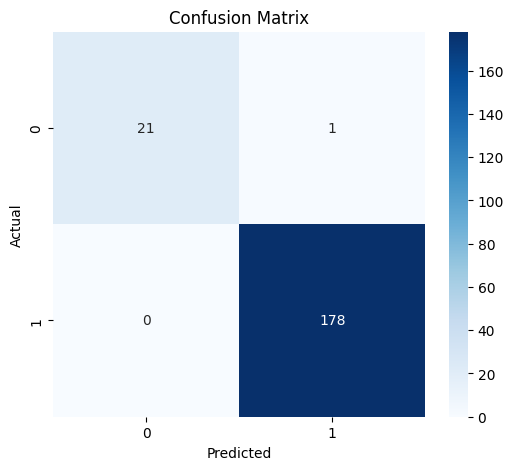

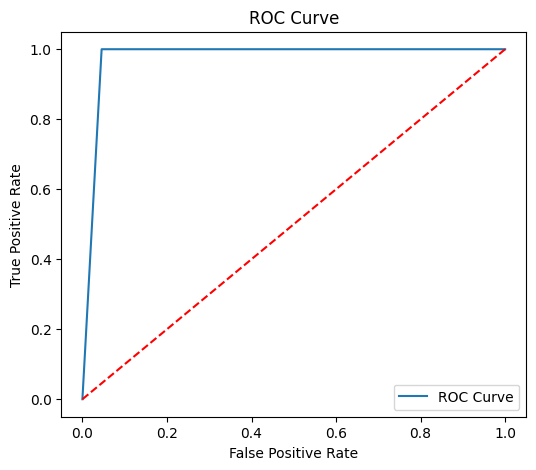


Feature Importance
               Feature  Importance
6        Credit amount    0.541297
7             Duration    0.366807
5     Checking account    0.053024
4      Saving accounts    0.038872
2                  Job    0.000000
0                  Age    0.000000
1                  Sex    0.000000
3              Housing    0.000000
8              Purpose    0.000000
9     Credit_per_Month    0.000000
10  Age_Duration_Ratio    0.000000


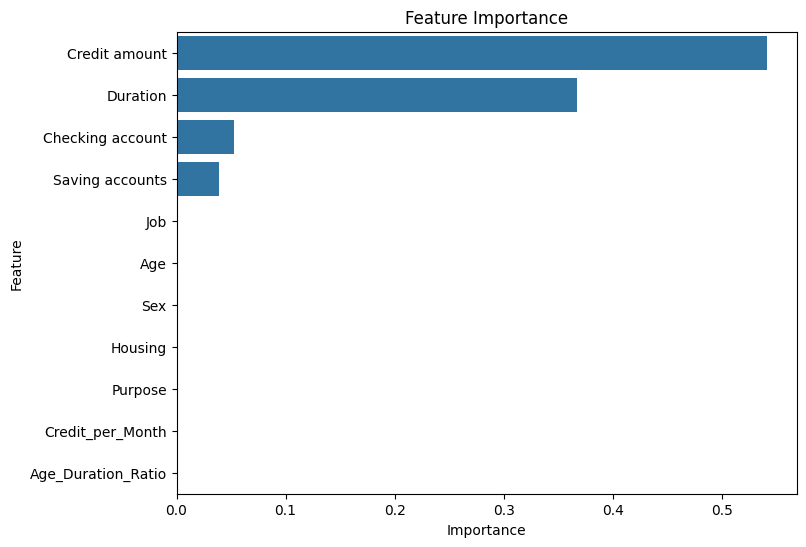


Project Completed Successfully.


In [2]:
# ==========================================================
# Creditworthiness Prediction Using Machine Learning
# Dataset: german_credit_data.csv
# ==========================================================

# ==========================
# Import Libraries
# ==========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("german_credit_data.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Shape :", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

# ==========================================================
# Remove Unwanted Column
# ==========================================================

if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

# ==========================================================
# Handle Missing Values
# ==========================================================

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

# ==========================================================
# Feature Engineering
# ==========================================================

df["Credit_per_Month"] = df["Credit amount"] / df["Duration"]

df["Age_Duration_Ratio"] = df["Age"] / df["Duration"]

# ==========================================================
# Create Target Column (Risk)
# 1 = Good Customer
# 0 = High Risk
# ==========================================================

df["Risk"] = np.where(
    (
        (df["Credit amount"] > 5000) &
        (df["Duration"] > 24) &
        (
            (df["Saving accounts"] == "little") |
            (df["Checking account"] == "little")
        )
    ),
    0,
    1
)

print("\nTarget Distribution")
print(df["Risk"].value_counts())

# ==========================================================
# Encode Categorical Columns
# ==========================================================

encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

# ==========================================================
# Features and Target
# ==========================================================

X = df.drop("Risk", axis=1)

y = df["Risk"]

# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# Models
# ==========================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )

}

results = []

# ==========================================================
# Train Models
# ==========================================================

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    probability = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    auc = roc_auc_score(y_test, probability)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("ROC AUC  :", auc)

    print("\nClassification Report\n")
    print(classification_report(y_test, prediction))

# ==========================================================
# Results Table
# ==========================================================

results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]

)

print("\nModel Comparison\n")
print(results_df)

# ==========================================================
# Best Model
# ==========================================================

best_model_name = results_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]["Model"]

print("\nBest Model :", best_model_name)

best_model = models[best_model_name]

# ==========================================================
# Confusion Matrix
# ==========================================================

prediction = best_model.predict(X_test)

cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# ==========================================================
# ROC Curve
# ==========================================================

probability = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probability)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ==========================================================
# Feature Importance
# ==========================================================

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\nFeature Importance")
    print(importance)

    plt.figure(figsize=(8,6))

    sns.barplot(
        x="Importance",
        y="Feature",
        data=importance
    )

    plt.title("Feature Importance")

    plt.show()

print("\nProject Completed Successfully.")